### Contextualização

#### Introdução

Este desafio utiliza o dataset [Chest X-Ray Images (Pneumonia) - Kaggle](https://www.kaggle.com/datasets/paultimothymooney/chest-xray-pneumonia) para estudar um problema de **classificação supervisionada de imagens médicas**. O objetivo é classificar radiografias de tórax em duas classes: **NORMAL**, quando não há sinais de pneumonia, e **PNEUMONIA**, quando a imagem apresenta indícios da doença.

O problema é relevante para a área de Reconhecimento de Padrões porque envolve a identificação de características visuais em imagens, como textura, contraste e regiões de opacidade pulmonar. Como os dados são imagens médicas, o processo exige etapas de pré-processamento, análise exploratória e avaliação do desempenho dos modelos.

O dataset é composto por radiografias torácicas pediátricas em formato JPEG, organizadas nos subconjuntos **train**, **val** e **test**, cada um contendo as classes **NORMAL** e **PNEUMONIA**. As imagens são provenientes de pacientes entre 1 e 5 anos de idade atendidos no Guangzhou Women and Children’s Medical Center, na China. Antes da disponibilização, as imagens passaram por um processo de controle de qualidade, com remoção de exames de baixa qualidade ou ilegíveis.

#### Exploração Inicial

A análise inicial dos dados mostra que o conjunto está dividido em três partes: treinamento, validação e teste. A distribuição das imagens por classe está da seguinte forma:

| Subconjunto | NORMAL | PNEUMONIA | Total |
| ----------- | -----: | --------: | ----: |
| Treino      |  1.342 |     3.876 | 5.218 |
| Validação   |      9 |         9 |    18 |
| Teste       |    235 |       391 |   626 |

Observa-se que o conjunto de treinamento é desbalanceado, com uma quantidade maior de imagens da classe **PNEUMONIA**. Esse desbalanceamento pode influenciar o treinamento dos modelos, tornando necessário o uso de métricas além da acurácia, como precisão, recall e F1-score.


In [22]:
# imports

import os
import time
import random
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

from torchvision import models
from torchvision.models import EfficientNet_B0_Weights

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report,
)

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Device:", device)
print("GPU:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "No GPU")

Device: cuda
GPU: NVIDIA GeForce 940MX


In [56]:
# settings

CLASS_NAMES = ["NORMAL", "PNEUMONIA"]
SPLIT_NAMES = ["train", "val", "test"]

MAX_EPOCHS = 20
PATIENCE = 4
LEARNING_RATE = 0.001
BATCH_SIZE = 32
NUM_WORKERS = 2
FINAL_THRESHOLD = 0.5

IMG_EXTENSIONS = ".jpeg"

# No primeiro experimento, treino e validação originais são unidos.
# Depois, 20% desse total é separado para validação e 80% permanece para treino.
SPLIT_VAL = 0.20

UNBALANCED_BEST_MODEL_PATH = "trained-models/best_mobilenetv2_unbalanced.pth"
UNDERSAMPLED_BEST_MODEL_PATH = "trained-models/best_mobilenetv2_undersampled.pth"
OVERSAMPLED_BEST_MODEL_PATH = "trained-models/best_mobilenetv2_oversampled.pth"

ORIGINAL_DATA_ROOT = Path("/home/wagner/Documents/MestradoIfes/datasets/chest_xray")
UNBALANCED_DATA_ROOT = Path("/home/wagner/Documents/MestradoIfes/datasets/experimento3/unbalanced_chest_xray")
UNDERSAMPLED_DATA_ROOT = Path("/home/wagner/Documents/MestradoIfes/datasets/experimento3/undersampled_chest_xray")
OVERSAMPLED_DATA_ROOT = Path("/home/wagner/Documents/MestradoIfes/datasets/experimento3/oversampled_chest_xray")

### Preparação

Na etapa de preparação dos dados, serão realizados dois experimentos com o objetivo de comparar o desempenho da rede neural em cenários com diferentes distribuições entre as classes **NORMAL** e **PNEUMONIA**.

O **dataset original** será utilizado apenas como fonte inicial das imagens, não sendo treinado diretamente na divisão original disponibilizada pelo Kaggle. A divisão original possui um conjunto de validação muito pequeno, com apenas 16 imagens. Por esse motivo, as imagens dos conjuntos originais de **treinamento** e **validação** serão agrupadas para formar uma nova base de treino e validação. O conjunto de **teste** original será mantido separado e será utilizado igualmente nos dois experimentos, permitindo uma comparação justa entre os modelos.

A distribuição inicial do dataset original é apresentada a seguir:

| Subconjunto | NORMAL | PNEUMONIA | Total |
| ----------- | -----: | --------: | ----: |
| Treinamento |  1.341 |     3.875 | 5.216 |
| Validação   |      8 |         8 |    16 |
| Teste       |    234 |       390 |   624 |
| **Total**   |  1.583 |     4.273 | 5.856 |

No **primeiro experimento**, será criado um dataset **desbalanceado** a partir da junção dos conjuntos originais de treinamento e validação. Após essa junção, 20% das imagens serão separadas para validação e os 80% restantes serão utilizados para treinamento. Essa divisão mantém o desbalanceamento natural entre as classes, com maior quantidade de imagens da classe **PNEUMONIA**.

A divisão utilizada no primeiro experimento será:

| Subconjunto | NORMAL | PNEUMONIA | Total |
| ----------- | -----: | --------: | ----: |
| Treinamento |  1.079 |     3.106 | 4.185 |
| Validação   |    270 |       777 | 1.047 |
| Teste       |    234 |       390 |   624 |
| **Total**   |  1.583 |     4.273 | 5.856 |

No **segundo experimento**, será criado um dataset **balanceado** utilizando a técnica de **undersampling** apenas no conjunto de treinamento. Essa técnica consiste em reduzir a quantidade de amostras da classe majoritária até que ela tenha o mesmo número de imagens da classe minoritária. Assim, serão mantidas todas as imagens da classe **NORMAL** no treinamento e será selecionada aleatoriamente a mesma quantidade de imagens da classe **PNEUMONIA**.

As imagens de **validação** e **teste** serão as mesmas utilizadas no primeiro experimento. Dessa forma, a única diferença entre os dois experimentos estará no conjunto de treinamento, permitindo avaliar diretamente o impacto do balanceamento sobre o aprendizado do modelo.

A divisão utilizada no segundo experimento será:

| Subconjunto | NORMAL | PNEUMONIA | Total |
| ----------- | -----: | --------: | ----: |
| Treinamento |  1.079 |     1.079 | 2.158 |
| Validação   |    270 |       777 | 1.047 |
| Teste       |    234 |       390 |   624 |
| **Total**   |  1.583 |     1.992 | 3.575 |

No **terceiro experimento**, será criado um dataset **balanceado** utilizando a técnica de **oversampling** apenas no conjunto de treinamento. Essa técnica consiste em aumentar a quantidade de amostras da classe minoritária até que ela tenha o mesmo número de imagens da classe majoritária. Assim, novas imagens da classe **NORMAL** serão criadas a partir das imagens já existentes, utilizando-se de técnicas de aumentos seguros para radiografias: flip horizontal, rotação pequena, pequenos deslocamentos e zoom.

As imagens de **validação** e **teste** serão as mesmas utilizadas no primeiro experimento.

A divisão utilizada no segundo experimento será:

| Subconjunto | NORMAL | PNEUMONIA | Total |
| ----------- | -----: | --------: | ----: |
| Treinamento |  3.106 |     3.106 | 6.212 |
| Validação   |    270 |       777 | 1.047 |
| Teste       |    234 |       390 |   624 |
| **Total**   |  1.583 |     1.992 | 3.575 |

Com essa organização, o primeiro experimento avalia o desempenho da rede neural em um cenário desbalanceado, o segundo avalia o efeito do balanceamento por undersampling no conjunto de treinamento, enquanto o terceiro avalia o efeito do balanceamento por oversampling. Como os conjuntos de validação e teste são mantidos iguais nos dois experimentos, a comparação entre os resultados torna-se mais consistente.


In [24]:
# Criação dos datasets dos experimentos a partir do dataset original.
#
# Experimento 1: dataset desbalanceado
# - une as imagens originais de train e val;
# - separa 20% desse total para validação;
# - mantém o teste original.
#
# Experimento 2: dataset balanceado por undersampling
# - mantém a mesma validação e o mesmo teste do experimento 1;
# - aplica undersampling apenas no treino.
#
# Experimento 3: dataset balanceado por oversampling da classe NORMAL
# - mantém a mesma validação e o mesmo teste do experimento 1;
# - mantém todas as imagens originais do treino;
# - gera novas imagens apenas da classe NORMAL até igualar a quantidade de PNEUMONIA;
# - usa apenas aumentos seguros para radiografias: flip horizontal, rotação pequena,
#   pequenos deslocamentos e zoom.
#
# Não é necessário executar este código toda vez, apenas quando quiser recriar os datasets.

import shutil
from tensorflow.keras.preprocessing.image import ImageDataGenerator, img_to_array, array_to_img


def list_image_paths_by_label(data_root, split_names):
    """Retorna os caminhos das imagens agrupados por classe, evitando duplicatas."""
    paths_by_label = {class_name: [] for class_name in CLASS_NAMES}
    seen_paths = set()

    for split_name in split_names:
        split_dir = Path(data_root) / split_name

        for class_name in CLASS_NAMES:
            class_dir = split_dir / class_name

            if not class_dir.exists():
                continue

            for image_path in class_dir.rglob("*"):
                if image_path.is_file() and image_path.suffix.lower() in IMG_EXTENSIONS:
                    resolved = image_path.resolve()
                    if resolved not in seen_paths:
                        paths_by_label[class_name].append(image_path)
                        seen_paths.add(resolved)

    return paths_by_label


def reset_dataset_dir(data_root):
    data_root = Path(data_root)

    if data_root.exists():
        shutil.rmtree(data_root)

    for split_name in SPLIT_NAMES:
        for class_name in CLASS_NAMES:
            (data_root / split_name / class_name).mkdir(parents=True, exist_ok=True)


def copy_pairs_to_dataset(split_pairs, output_root, image_size=(224, 224)):
    output_root = Path(output_root)

    for split_name, pairs in split_pairs.items():
        for i, (image_path, class_name) in enumerate(pairs):
            dst_name = f"{class_name}_{split_name}_{i:05d}_{Path(image_path).name}"
            dst_path = output_root / split_name / class_name / dst_name

            image = Image.open(image_path).convert("RGB")
            image = image.resize(image_size)
            image.save(dst_path)

def save_augmented_image(image_path, dst_path, datagen, image_size=(224, 224), seed=None):
    """
    Gera uma nova imagem aumentada a partir de uma imagem original.

    As transformações são restritas para preservar a orientação anatômica:
    - sem flip vertical;
    - sem shear;
    - sem alteração forte de cor;
    - apenas flip horizontal, rotação pequena, pequenos deslocamentos e zoom.
    """
    image = Image.open(image_path).convert("RGB")
    image = image.resize(image_size)

    image_array = img_to_array(image)
    image_array = np.expand_dims(image_array, axis=0)

    iterator = datagen.flow(
        image_array,
        batch_size=1,
        shuffle=False,
        seed=seed
    )

    augmented_array = next(iterator)[0]
    augmented_image = array_to_img(augmented_array)

    augmented_image.save(dst_path)
    
def print_dataset_counts(data_root):
    for split_name in SPLIT_NAMES:
        print("|", split_name.upper())
        total = 0

        for class_name in CLASS_NAMES:
            class_dir = Path(data_root) / split_name / class_name
            n = len([p for p in class_dir.rglob("*") if p.is_file() and p.suffix.lower() in IMG_EXTENSIONS])
            total += n
            print("|--", class_name, ":", n)

        print("Total", split_name, ":", total)


def split_train_val_from_original(original_root=ORIGINAL_DATA_ROOT):
    """Une train+val originais e cria uma nova divisão train/val por classe."""
    paths_by_label = list_image_paths_by_label(original_root, split_names=["train", "val"])

    split_pairs = {"train": [], "val": [], "test": []}

    for class_name in CLASS_NAMES:
        class_paths = sorted(paths_by_label[class_name])

        val_count = int(round(len(class_paths) * SPLIT_VAL))
        val_count = min(max(val_count, 1), len(class_paths) - 1)

        train_paths, val_paths = train_test_split(
            class_paths,
            test_size=val_count,
            random_state=SEED,
            shuffle=True
        )

        split_pairs["train"].extend((path, class_name) for path in train_paths)
        split_pairs["val"].extend((path, class_name) for path in val_paths)

    test_paths_by_label = list_image_paths_by_label(original_root, split_names=["test"])

    for class_name in CLASS_NAMES:
        split_pairs["test"].extend((path, class_name) for path in sorted(test_paths_by_label[class_name]))

    return split_pairs


def create_unbalanced_dataset(original_root=ORIGINAL_DATA_ROOT, output_root=UNBALANCED_DATA_ROOT):
    """Cria o dataset desbalanceado do primeiro experimento."""
    split_pairs = split_train_val_from_original(original_root)

    reset_dataset_dir(output_root)
    copy_pairs_to_dataset(split_pairs, output_root)

    print("Unbalanced dataset created successfully in:", output_root)
    print_dataset_counts(output_root)


def create_undersampled_dataset(original_root=ORIGINAL_DATA_ROOT, output_root=UNDERSAMPLED_DATA_ROOT):
    """Cria o dataset balanceado do segundo experimento com undersampling apenas no treino."""
    split_pairs = split_train_val_from_original(original_root)
    train_pairs = split_pairs["train"]

    train_paths_by_label = {class_name: [] for class_name in CLASS_NAMES}
    for image_path, class_name in train_pairs:
        train_paths_by_label[class_name].append(image_path)

    min_train_count = min(len(paths) for paths in train_paths_by_label.values())
    rng = random.Random(SEED)

    balanced_train_pairs = []
    for class_name in CLASS_NAMES:
        selected_paths = rng.sample(train_paths_by_label[class_name], min_train_count)
        balanced_train_pairs.extend((path, class_name) for path in selected_paths)

    balanced_split_pairs = {
        "train": balanced_train_pairs,
        "val": split_pairs["val"],
        "test": split_pairs["test"]
    }

    reset_dataset_dir(output_root)
    copy_pairs_to_dataset(balanced_split_pairs, output_root)

    print("Balanced dataset created successfully in:", output_root)
    print_dataset_counts(output_root)

def create_oversampled_dataset(original_root=ORIGINAL_DATA_ROOT, output_root=OVERSAMPLED_DATA_ROOT):
    """
    Cria o dataset balanceado do terceiro experimento com oversampling da classe NORMAL
    apenas no conjunto de treinamento.

    A validação e o teste são mantidos iguais aos do experimento desbalanceado.
    """
    split_pairs = split_train_val_from_original(original_root)

    train_pairs = split_pairs["train"]

    train_paths_by_label = {class_name: [] for class_name in CLASS_NAMES}
    for image_path, class_name in train_pairs:
        train_paths_by_label[class_name].append(image_path)

    normal_train_paths = train_paths_by_label["NORMAL"]
    pneumonia_train_paths = train_paths_by_label["PNEUMONIA"]

    normal_count = len(normal_train_paths)
    pneumonia_count = len(pneumonia_train_paths)

    if normal_count >= pneumonia_count:
        raise ValueError(
            "A classe NORMAL já possui quantidade igual ou maior que PNEUMONIA no treino. "
            "Oversampling da classe NORMAL não é necessário."
        )

    images_to_generate = pneumonia_count - normal_count

    normal_datagen = ImageDataGenerator(
        rotation_range=10,        # pequena inclinação; anatomia permanece em pé
        width_shift_range=0.1,
        height_shift_range=0.1,
        zoom_range=0.1,
        horizontal_flip=True,     # pulmões esquerdo/direito são aproximadamente simétricos
        vertical_flip=False,      # não usar flip vertical em anatomia médica
        shear_range=0.0,          # não aplicar cisalhamento
        brightness_range=None,    # evita alteração forte de cor/brilho
        fill_mode="nearest"
    )

    oversampled_split_pairs = {
        "train": split_pairs["train"],
        "val": split_pairs["val"],
        "test": split_pairs["test"]
    }

    reset_dataset_dir(output_root)

    # Copia todas as imagens originais de train/val/test.
    copy_pairs_to_dataset(oversampled_split_pairs, output_root)

    rng = random.Random(SEED)

    # Gera novas imagens apenas para a classe NORMAL do treino.
    for i in range(images_to_generate):
        source_path = rng.choice(normal_train_paths)

        dst_name = f"NORMAL_train_aug_{i:05d}_{Path(source_path).stem}.jpeg"
        dst_path = Path(output_root) / "train" / "NORMAL" / dst_name

        save_augmented_image(
            image_path=source_path,
            dst_path=dst_path,
            datagen=normal_datagen,
            image_size=(224, 224),
            seed=SEED + i
        )

    print("Oversampled dataset created successfully in:", output_root)
    print("Generated NORMAL images:", images_to_generate)
    print_dataset_counts(output_root)
    
# Quando for necessário recriar os datasets, descomente as chamadas abaixo.
#create_oversampled_dataset()
#create_undersampled_dataset()
#create_unbalanced_dataset()


In [25]:
# Classe que representa o dataset

class ChestXRayDataset(Dataset):
    def __init__(self, samples, transform=None):
        self.samples = samples
        self.transform = transform
        self.classes = CLASS_NAMES
        self.class_to_idx = {
            class_name: idx for idx, class_name in enumerate(self.classes)
        }

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, index):
        image_path, label = self.samples[index]
        image = Image.open(image_path).convert("RGB")

        if self.transform is not None:
            image = self.transform(image)

        return image, label
    
# funcoes para montar os datasets de treino, validação e teste
def read_samples_by_folder(data_root, split_name):
    split_dir = Path(data_root) / split_name

    samples = []
    seen_paths = set()

    for label in CLASS_NAMES:
        class_dir = split_dir / label

        for image_path in class_dir.rglob("*"):
            if image_path.is_file() and image_path.suffix.lower() in IMG_EXTENSIONS:
                resolved = image_path.resolve()
                
                if resolved not in seen_paths:
                    samples.append((str(image_path), CLASS_NAMES.index(label)))
                    seen_paths.add(resolved)
                    
    samples = sorted(samples, key=lambda x: x[0])
    return samples

def print_class_counts(name, samples):
    counts = Counter(label for _, label in samples)

    print(f"{name} images:", len(samples))
    print(f"|--NORMAL:", counts.get(0, 0))
    print(f"|--PNEUMONIA:", counts.get(1, 0))

In [26]:
unbalanced_train_samples = read_samples_by_folder(UNBALANCED_DATA_ROOT, "train")
unbalanced_val_samples = read_samples_by_folder(UNBALANCED_DATA_ROOT, "val")
unbalanced_test_samples = read_samples_by_folder(UNBALANCED_DATA_ROOT, "test")

print_class_counts("Train", unbalanced_train_samples)
print_class_counts("Validation", unbalanced_val_samples)
print_class_counts("Test", unbalanced_test_samples)

total_images = len(unbalanced_train_samples) + len(unbalanced_val_samples) + len(unbalanced_test_samples)
print("Total images used:", total_images)

Train images: 4185
|--NORMAL: 1079
|--PNEUMONIA: 3106
Validation images: 1047
|--NORMAL: 270
|--PNEUMONIA: 777
Test images: 624
|--NORMAL: 234
|--PNEUMONIA: 390
Total images used: 5856


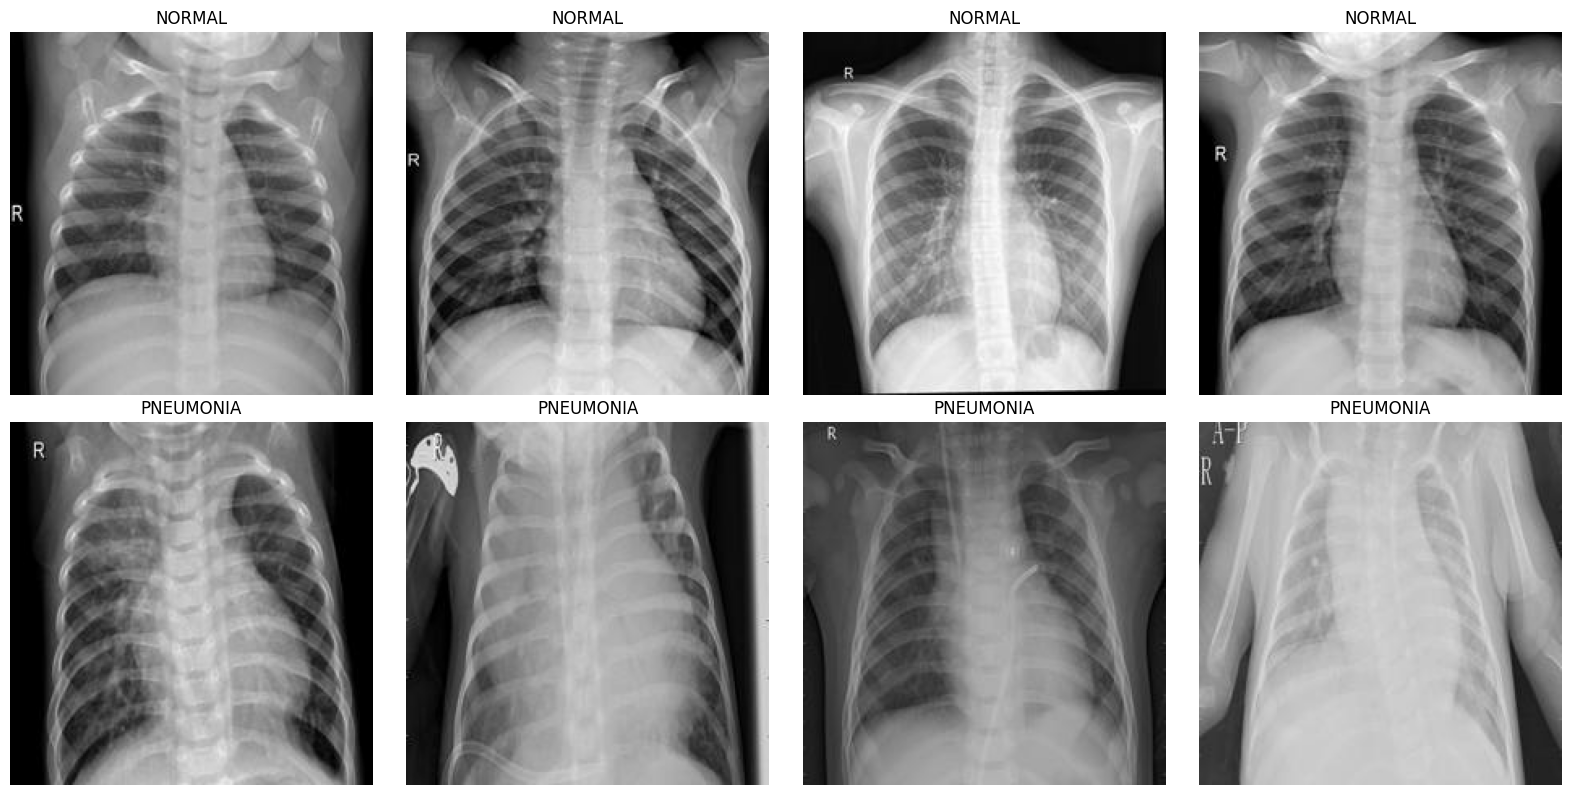

In [27]:
# Cell 7 — Show sample images

def show_sample_images(samples, n_per_class=2):
    fig, axes = plt.subplots(
        len(CLASS_NAMES),
        n_per_class,
        figsize=(4 * n_per_class, 4 * len(CLASS_NAMES))
    )

    for class_name in CLASS_NAMES:
        class_idx = CLASS_NAMES.index(class_name)
        class_samples = [path for path, y in samples if y == class_idx]

        if len(class_samples) == 0:
            continue

        chosen_paths = random.sample(
            class_samples,
            min(n_per_class, len(class_samples))
        )

        for i, image_path in enumerate(chosen_paths):
            image = Image.open(image_path)
            axes[class_idx, i].imshow(image, cmap="gray")
            axes[class_idx, i].set_title(class_name)
            axes[class_idx, i].axis("off")

    plt.tight_layout()
    plt.show()


show_sample_images(unbalanced_train_samples, n_per_class=4)

### Aplicação das Técnicas de Aprendizado de Máquina

Para a etapa de classificação foi adotada uma abordagem baseada em redes neurais convolucionais, por serem modelos adequados para tarefas de reconhecimento de padrões em imagens. Esse tipo de arquitetura permite a extração automática de características visuais relevantes, como bordas, texturas, formas e padrões locais, reduzindo a necessidade de definição manual de atributos.

O modelo escolhido foi o MobileNetV2, uma arquitetura eficiente, projetada para apresentar bom desempenho com baixo custo computacional. Sua utilização é adequada ao problema proposto, pois combina capacidade de extração de características com leveza em termos de número de parâmetros e operações, tornando o treinamento e a inferência mais viáveis mesmo em ambientes com recursos limitados.

Neste trabalho, foi utilizado o modelo MobileNetV2 com pesos pré-treinados disponibilizados pelo PyTorch/TorchVision. Esses pesos foram originalmente treinados sobre o conjunto ImageNet, permitindo o uso de aprendizado por transferência. Dessa forma, as camadas iniciais do modelo já possuem filtros capazes de identificar padrões visuais genéricos, enquanto as camadas finais podem ser adaptadas para a tarefa específica de classificação entre imagens normais e imagens com pneumonia.

Além disso, foi aplicado o pré-processamento padrão associado aos pesos pré-treinados do MobileNetV2 no TorchVision. Esse procedimento inclui o redimensionamento da imagem, seguido de um recorte central para a dimensão de entrada esperada pelo modelo, principalmente ajustando as imagens para 224 × 224 pixels. Em seguida, os valores dos pixels são reescalados e normalizados com médias e desvios-padrão compatíveis com o treinamento original no ImageNet.

A documentação indica que MobileNet_V2_Weights.DEFAULT corresponde aos pesos IMAGENET1K_V2, com cerca de 3,5 milhões de parâmetros, 0,30 GFLOPS e tamanho aproximado de 13,6 MB. Para esses pesos, as transformações fazem resize com crop central para 224 pixels e normalização com mean=[0.485, 0.456, 0.406] e std=[0.229, 0.224, 0.225].


In [28]:

unbalanced_weights = EfficientNet_B0_Weights.DEFAULT
unbalanced_preprocess = unbalanced_weights.transforms()

unbalanced_train_dataset = ChestXRayDataset(unbalanced_train_samples, transform=unbalanced_preprocess)
unbalanced_val_dataset = ChestXRayDataset(unbalanced_val_samples, transform=unbalanced_preprocess)
unbalanced_test_dataset = ChestXRayDataset(unbalanced_test_samples, transform=unbalanced_preprocess)

print("Dimensões da imagem após transformação:", unbalanced_train_dataset[0][0].shape)

Dimensões da imagem após transformação: torch.Size([3, 224, 224])


A classe `Dataset` armazena as amostras e seus labels correspondentes, e `DataLoader` envolve o `Dataset` em um iterável para permitir acesso fácil às amostras. Os seguinte parâmetros são utilizados:

`dataset` (`Dataset`) – conjunto de dados a partir do qual os dados serão carregados.

`batch_size` (`int`, opcional) – quantas amostras carregar por lote/batch. Padrão: `1`.

`shuffle` (`bool`, opcional) – defina como `True` para que os dados sejam embaralhados novamente a cada época. Padrão: `False`.

`num_workers` (`int`, opcional) – quantos subprocessos usar para o carregamento dos dados. `0` significa que os dados serão carregados no processo principal. Padrão: `0`.

`pin_memory` (`bool`, opcional) – se `True`, o data loader copiará os Tensores para memória fixada do dispositivo/CUDA antes de retorná-los.

In [29]:
pin_memory = torch.cuda.is_available()

unbalanced_train_loader = DataLoader(
    unbalanced_train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=pin_memory
)

unbalanced_val_loader = DataLoader(
    unbalanced_val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=pin_memory
)

unbalanced_test_loader = DataLoader(
    unbalanced_test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=pin_memory
)

Faz transfer learning com a MobileNetV2: carrega um modelo pré-treinado, congela suas camadas principais e substitui a camada final para adaptar o modelo à classificação binária entre raio-X normal e raio-X com pneumonia.

A última camada é trocada por uma camada linear com apenas 1 neurônio de saída.

In [30]:
unbalanced_model = models.efficientnet_b0(weights=unbalanced_weights)
for param in unbalanced_model.parameters():
    param.requires_grad = False
unbalanced_model.classifier[1] = nn.Linear(unbalanced_model.classifier[1].in_features, 1)

unbalanced_model = unbalanced_model.to(device)


trainable_params = sum(p.numel() for p in unbalanced_model.parameters() if p.requires_grad)
total_params = sum(p.numel() for p in unbalanced_model.parameters())

print("Trainable parameters:", trainable_params)
print("Total parameters:", total_params)

Trainable parameters: 1281
Total parameters: 4008829


### Treinamento da RN no dataset desbalanceado

O *early stopping* interrompe o treinamento quando a perda não melhora por várias épocas.

Neste notebook: `MAX_EPOCHS = 20`  e  `PATIENCE = 4` (Quantas épocas sem melhoria esperar)

O melhor modelo é salvo automaticamente.

`BCEWithLogitsLoss`: a função de perda usada para medir o erro do modelo. É adequada para classificação binária pois ombina duas etapas em uma só: sigmoid + binary cross-entropy.

`Adam`: o otimizador responsável por atualizar os pesos treináveis do modelo durante o treinamento. É uma variação eficiente do gradiente descendente.

In [31]:
def evaluate_during_training(model, data_loader, criterion):
    model.eval()

    running_loss = 0.0
    running_corrects = 0
    total_samples = 0

    with torch.no_grad():
        for inputs, labels in data_loader:
            inputs = inputs.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True).unsqueeze(1).float()

            outputs = model(inputs)
            loss = criterion(outputs, labels)

            predictions = torch.sigmoid(outputs).round()

            batch_size_current = labels.size(0)
            running_loss += loss.item() * batch_size_current
            running_corrects += torch.sum(predictions == labels).item()
            total_samples += batch_size_current

    epoch_loss = running_loss / max(total_samples, 1)
    epoch_accuracy = running_corrects / max(total_samples, 1)

    return epoch_loss, epoch_accuracy

def train_model(
    model,
    train_loader,
    val_loader,
    num_epochs=20,
    learning_rate=0.001,
    patience=4,
    best_model_path="best_model.pth"
):

    criterion = nn.BCEWithLogitsLoss()
    optimizer = optim.Adam(
        filter(lambda p: p.requires_grad, model.parameters()),
        lr=learning_rate
    )

    amp_enabled = torch.cuda.is_available()
    scaler = torch.amp.GradScaler("cuda", enabled=amp_enabled)

    history = {
        "train_loss": [],
        "train_accuracy": [],
        "val_loss": [],
        "val_accuracy": []
    }

    best_val_loss = float("inf")
    epochs_without_improvement = 0
    best_epoch = 0

    start_time = time.time()

    for epoch in range(num_epochs):
        model.train()

        running_loss = 0.0
        running_corrects = 0
        total_samples = 0

        for inputs, labels in train_loader:
            inputs = inputs.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True).unsqueeze(1).float()

            optimizer.zero_grad()

            with torch.amp.autocast("cuda", enabled=amp_enabled):
                outputs = model(inputs)
                loss = criterion(outputs, labels)

            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()

            predictions = torch.sigmoid(outputs).round()

            batch_size_current = labels.size(0)
            running_loss += loss.item() * batch_size_current
            running_corrects += torch.sum(predictions == labels).item()
            total_samples += batch_size_current

        train_loss = running_loss / max(total_samples, 1)
        train_accuracy = running_corrects / max(total_samples, 1)

        val_loss, val_accuracy = evaluate_during_training(
            model=model,
            data_loader=val_loader,
            criterion=criterion
        )

        history["train_loss"].append(train_loss)
        history["train_accuracy"].append(train_accuracy)
        history["val_loss"].append(val_loss)
        history["val_accuracy"].append(val_accuracy)

        print(
            f"Epoch [{epoch+1}/{num_epochs}], "
            f"Train Loss: {train_loss:.4f}, "
            f"Train Acc: {train_accuracy:.4f}, "
            f"Val Loss: {val_loss:.4f}, "
            f"Val Acc: {val_accuracy:.4f}"
        )

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_epoch = epoch + 1
            epochs_without_improvement = 0
            torch.save(model.state_dict(), best_model_path)
            print(f"Best model saved at epoch {best_epoch}.")
        else:
            epochs_without_improvement += 1
            print(f"No improvement for {epochs_without_improvement} epoch(s).")

        if epochs_without_improvement >= patience:
            print("Early stopping activated.")
            break

    training_time_seconds = time.time() - start_time
    epochs_done = len(history["train_loss"])

    print("Training complete.")
    print(f"Best epoch: {best_epoch}")
    print(f"Training time: {training_time_seconds:.2f} seconds or {training_time_seconds/60:.2f} minutes")

    return history, training_time_seconds, best_epoch, epochs_done

In [32]:
# Inicia o treinamento

unb_history, unb_training_time_seconds, unb_best_epoch, unb_epochs_done = train_model(
    model=unbalanced_model,
    train_loader=unbalanced_train_loader,
    val_loader=unbalanced_val_loader,
    num_epochs=MAX_EPOCHS,
    learning_rate=LEARNING_RATE,
    patience=PATIENCE,
    best_model_path=UNBALANCED_BEST_MODEL_PATH
)

Epoch [1/20], Train Loss: 0.3683, Train Acc: 0.8514, Val Loss: 0.2284, Val Acc: 0.9370
Best model saved at epoch 1.
Epoch [2/20], Train Loss: 0.2192, Train Acc: 0.9247, Val Loss: 0.1844, Val Acc: 0.9436
Best model saved at epoch 2.
Epoch [3/20], Train Loss: 0.1886, Train Acc: 0.9329, Val Loss: 0.1603, Val Acc: 0.9446
Best model saved at epoch 3.
Epoch [4/20], Train Loss: 0.1759, Train Acc: 0.9338, Val Loss: 0.1498, Val Acc: 0.9475
Best model saved at epoch 4.
Epoch [5/20], Train Loss: 0.1618, Train Acc: 0.9405, Val Loss: 0.1401, Val Acc: 0.9542
Best model saved at epoch 5.
Epoch [6/20], Train Loss: 0.1527, Train Acc: 0.9422, Val Loss: 0.1400, Val Acc: 0.9542
Best model saved at epoch 6.
Epoch [7/20], Train Loss: 0.1492, Train Acc: 0.9438, Val Loss: 0.1339, Val Acc: 0.9561
Best model saved at epoch 7.
Epoch [8/20], Train Loss: 0.1415, Train Acc: 0.9474, Val Loss: 0.1302, Val Acc: 0.9599
Best model saved at epoch 8.
Epoch [9/20], Train Loss: 0.1425, Train Acc: 0.9470, Val Loss: 0.1270, V

### Avaliação dos Resultados

Exibe as curvas de treinamento:

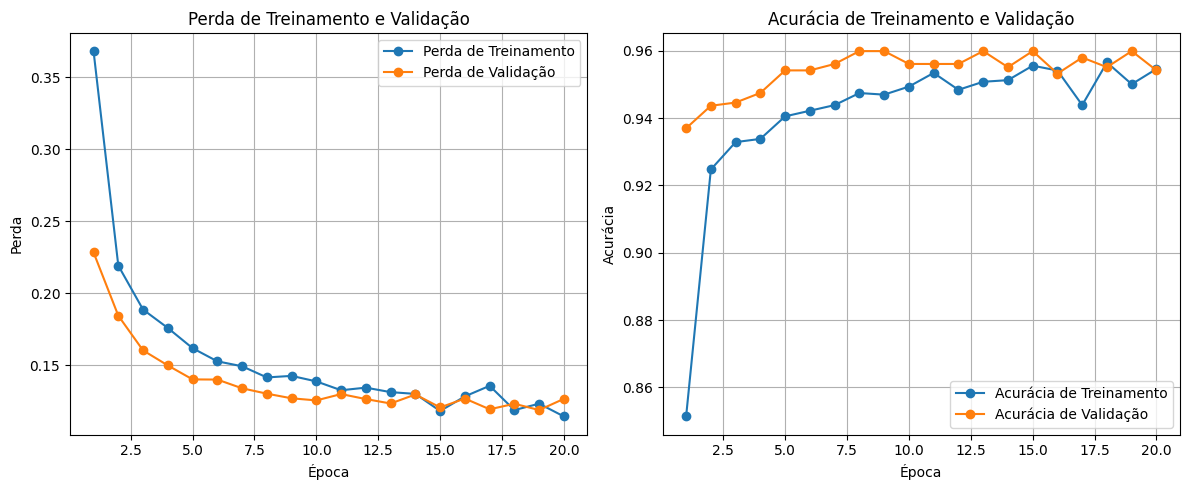

In [33]:
def plot_training_curves(history):
    
    epochs = range(1, len(history["train_loss"]) + 1)

    plt.figure(figsize=(12, 5))

    plt.subplot(1, 2, 1)
    plt.plot(epochs, history["train_loss"], marker="o", label="Perda de Treinamento")
    plt.plot(epochs, history["val_loss"], marker="o", label="Perda de Validação")
    plt.xlabel("Época")
    plt.ylabel("Perda")
    plt.title("Perda de Treinamento e Validação")
    plt.legend()
    plt.grid(True)

    plt.subplot(1, 2, 2)
    plt.plot(epochs, history["train_accuracy"], marker="o", label="Acurácia de Treinamento")
    plt.plot(epochs, history["val_accuracy"], marker="o", label="Acurácia de Validação")
    plt.xlabel("Época")
    plt.ylabel("Acurácia")
    plt.title("Acurácia de Treinamento e Validação")
    plt.legend()
    plt.grid(True)

    plt.tight_layout()
    plt.show()
    
plot_training_curves(unb_history)

Carrega o melhor modelo que foi salvo em arquivo:

In [34]:
unbalanced_model.load_state_dict(torch.load(UNBALANCED_BEST_MODEL_PATH, map_location=device, weights_only=True))
unbalanced_model = unbalanced_model.to(device)

print("Loaded best model:", UNBALANCED_BEST_MODEL_PATH)

Loaded best model: trained-models/best_mobilenetv2_unbalanced.pth


A avaliação dos resultados é feita no conjunto de testes:

Obs.: o threshold é o valor de corte usado para transformar a probabilidade calculada pela rede (entre 0 e 1) em uma decisão final (Pneumonia ou não).

In [35]:
def evaluate_model(model, test_loader, threshold=0.5):
    model.eval()

    all_predictions = []
    all_labels = []
    all_probabilities = []

    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs = inputs.to(device, non_blocking=True)

            outputs = model(inputs)
            probabilities = torch.sigmoid(outputs).squeeze(1).cpu()
            predictions = (probabilities >= threshold).long()

            all_probabilities.extend(probabilities.tolist())
            all_predictions.extend(predictions.tolist())
            all_labels.extend(labels.tolist())

    test_accuracy = accuracy_score(all_labels, all_predictions)
    test_precision = precision_score(all_labels, all_predictions, zero_division=0)
    test_recall = recall_score(all_labels, all_predictions, zero_division=0)
    test_f1 = f1_score(all_labels, all_predictions, zero_division=0)

    print(f"Threshold: {threshold}")
    print(f"Test Accuracy: {test_accuracy:.4f}")
    print(f"Test Precision: {test_precision:.4f}")
    print(f"Test Recall: {test_recall:.4f}")
    print(f"Test F1 Score: {test_f1:.4f}")

    print("\nClassification Report:")
    print(
        classification_report(
            all_labels,
            all_predictions,
            target_names=CLASS_NAMES,
            zero_division=0
        )
    )

    return all_labels, all_predictions, all_probabilities


unb_all_labels, unb_all_predictions, unb_all_probabilities = evaluate_model(
    unbalanced_model,
    unbalanced_test_loader,
    threshold=FINAL_THRESHOLD
)

Threshold: 0.5
Test Accuracy: 0.8141
Test Precision: 0.7740
Test Recall: 0.9923
Test F1 Score: 0.8697

Classification Report:
              precision    recall  f1-score   support

      NORMAL       0.98      0.52      0.68       234
   PNEUMONIA       0.77      0.99      0.87       390

    accuracy                           0.81       624
   macro avg       0.87      0.75      0.77       624
weighted avg       0.85      0.81      0.80       624



#### Refinamento do Threshold

Vamos comparar as métricas para diferentes thresholds.

In [36]:
threshold_rows = []

for th in [0.50, 0.55, 0.60, 0.65, 0.70]:
    preds = [1 if p >= th else 0 for p in unb_all_probabilities]

    row = {
        "threshold": th,
        "accuracy": accuracy_score(unb_all_labels, preds),
        "precision": precision_score(unb_all_labels, preds, zero_division=0),
        "recall": recall_score(unb_all_labels, preds, zero_division=0),
        "f1_score": f1_score(unb_all_labels, preds, zero_division=0),
    }

    threshold_rows.append(row)

threshold_df = pd.DataFrame(threshold_rows)
display(threshold_df)

,threshold,accuracy,precision,recall,f1_score
0,0.50,0.814103,0.774000,0.992308,0.869663
1,0.55,0.822115,0.781818,0.992308,0.874576
2,0.60,0.831731,0.793814,0.987179,0.880000
3,0.65,0.836538,0.801255,0.982051,0.882488
4,0.70,0.846154,0.814103,0.976923,0.888112


##### Matriz de confusão

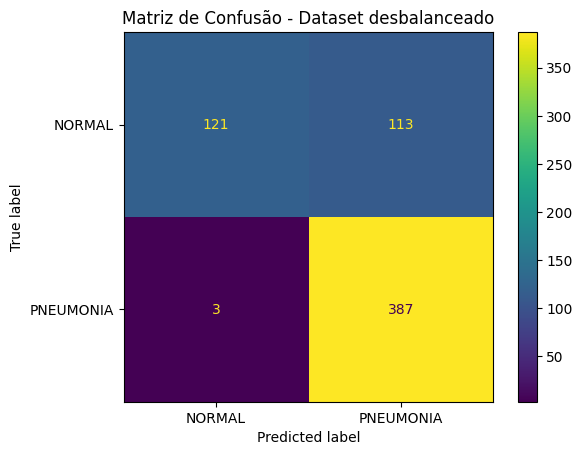

In [37]:
unb_conf_matrix = confusion_matrix(unb_all_labels, unb_all_predictions)

disp = ConfusionMatrixDisplay(
    confusion_matrix=unb_conf_matrix,
    display_labels=CLASS_NAMES
)

disp.plot(values_format="d")
plt.title("Matriz de Confusão - Dataset desbalanceado")
plt.show()

### Experimento com o dataset balanceado por UNDERSAMPLING

Neste segundo experimento, o conjunto de **treinamento** e o conjunto de **validação** foram balanceados por undersampling. O conjunto de **teste** foi mantido igual ao dataset desbalanceado, sem undersampling, para que a avaliação final continue sendo feita sobre a mesma distribuição nos dois experimentos.

In [38]:
balanced_train_samples = read_samples_by_folder(UNDERSAMPLED_DATA_ROOT, "train")
balanced_val_samples = read_samples_by_folder(UNDERSAMPLED_DATA_ROOT, "val")
balanced_test_samples = read_samples_by_folder(UNDERSAMPLED_DATA_ROOT, "test")

print_class_counts("Train", balanced_train_samples)
print_class_counts("Validation", balanced_val_samples)
print_class_counts("Test", balanced_test_samples)

total_balanced_images = len(balanced_train_samples) + len(balanced_val_samples) + len(balanced_test_samples)
print("Total images used:", total_balanced_images)

Train images: 2158
|--NORMAL: 1079
|--PNEUMONIA: 1079
Validation images: 1047
|--NORMAL: 270
|--PNEUMONIA: 777
Test images: 624
|--NORMAL: 234
|--PNEUMONIA: 390
Total images used: 3829


In [39]:

balanced_weights = EfficientNet_B0_Weights.DEFAULT
balanced_preprocess = balanced_weights.transforms()

balanced_train_dataset = ChestXRayDataset(balanced_train_samples, transform=balanced_preprocess)
balanced_val_dataset = ChestXRayDataset(balanced_val_samples, transform=balanced_preprocess)
balanced_test_dataset = ChestXRayDataset(balanced_test_samples, transform=balanced_preprocess)

In [40]:
balanced_train_loader = DataLoader(
    balanced_train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=pin_memory
)

balanced_val_loader = DataLoader(
    balanced_val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=pin_memory
)

balanced_test_loader = DataLoader(
    balanced_test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=pin_memory
)

In [41]:
balanced_model = models.efficientnet_b0(weights=balanced_weights)
for param in balanced_model.parameters():
    param.requires_grad = False
balanced_model.classifier[1] = nn.Linear(balanced_model.classifier[1].in_features, 1)

balanced_model = balanced_model.to(device)


trainable_params = sum(p.numel() for p in balanced_model.parameters() if p.requires_grad)
total_params = sum(p.numel() for p in balanced_model.parameters())

In [42]:
# Inicia o treinamento

b_history, b_training_time_seconds, b_best_epoch, b_epochs_done = train_model(
    model=balanced_model,
    train_loader=balanced_train_loader,
    val_loader=balanced_val_loader,
    num_epochs=MAX_EPOCHS,
    learning_rate=LEARNING_RATE,
    patience=PATIENCE,
    best_model_path=UNDERSAMPLED_BEST_MODEL_PATH
)

Epoch [1/20], Train Loss: 0.4528, Train Acc: 0.8587, Val Loss: 0.3629, Val Acc: 0.8816
Best model saved at epoch 1.
Epoch [2/20], Train Loss: 0.2879, Train Acc: 0.9087, Val Loss: 0.2532, Val Acc: 0.9093
Best model saved at epoch 2.
Epoch [3/20], Train Loss: 0.2456, Train Acc: 0.9129, Val Loss: 0.2071, Val Acc: 0.9322
Best model saved at epoch 3.
Epoch [4/20], Train Loss: 0.2200, Train Acc: 0.9226, Val Loss: 0.2009, Val Acc: 0.9312
Best model saved at epoch 4.
Epoch [5/20], Train Loss: 0.2143, Train Acc: 0.9212, Val Loss: 0.1826, Val Acc: 0.9370
Best model saved at epoch 5.
Epoch [6/20], Train Loss: 0.1990, Train Acc: 0.9263, Val Loss: 0.1902, Val Acc: 0.9312
No improvement for 1 epoch(s).
Epoch [7/20], Train Loss: 0.1903, Train Acc: 0.9300, Val Loss: 0.1874, Val Acc: 0.9293
No improvement for 2 epoch(s).
Epoch [8/20], Train Loss: 0.1815, Train Acc: 0.9398, Val Loss: 0.1739, Val Acc: 0.9341
Best model saved at epoch 8.
Epoch [9/20], Train Loss: 0.1703, Train Acc: 0.9458, Val Loss: 0.180

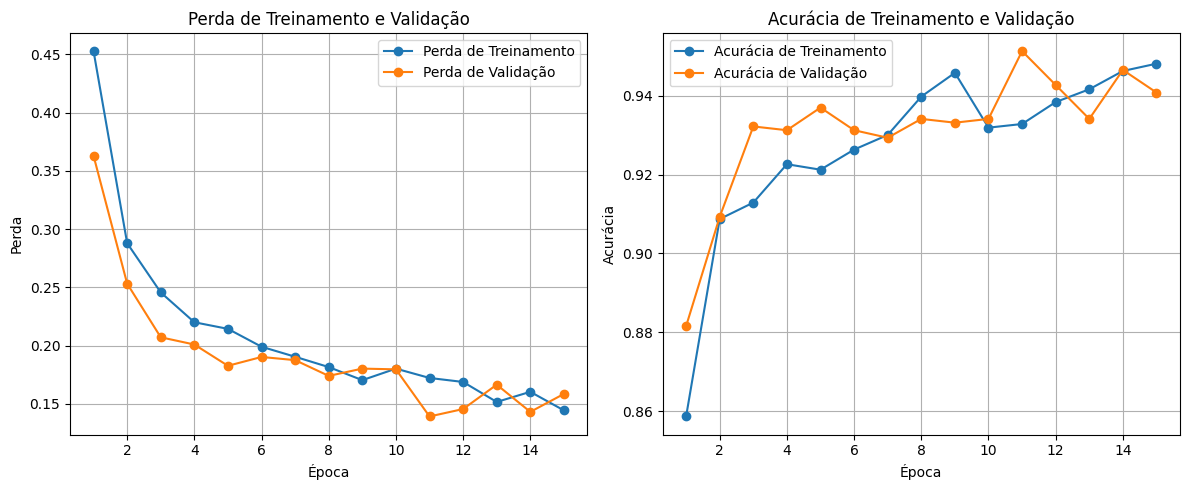

In [43]:
plot_training_curves(b_history)

In [78]:
balanced_model.load_state_dict(torch.load(UNDERSAMPLED_BEST_MODEL_PATH, map_location=device, weights_only=True))
balanced_model = balanced_model.to(device)

print("Loaded best model:", UNDERSAMPLED_BEST_MODEL_PATH)

#testa varios valores de threshold
for th in [0.50, 0.55, 0.60, 0.65, 0.70]:
    b_all_labels, b_all_predictions, b_all_probabilities = evaluate_model(
        balanced_model,
        balanced_test_loader,
        threshold=th
    )

Loaded best model: trained-models/best_mobilenetv2_undersampled.pth
Threshold: 0.5
Test Accuracy: 0.8333
Test Precision: 0.7992
Test Recall: 0.9795
Test F1 Score: 0.8802

Classification Report:
              precision    recall  f1-score   support

      NORMAL       0.95      0.59      0.73       234
   PNEUMONIA       0.80      0.98      0.88       390

    accuracy                           0.83       624
   macro avg       0.87      0.78      0.80       624
weighted avg       0.85      0.83      0.82       624

Threshold: 0.55
Test Accuracy: 0.8397
Test Precision: 0.8098
Test Recall: 0.9718
Test F1 Score: 0.8834

Classification Report:
              precision    recall  f1-score   support

      NORMAL       0.93      0.62      0.74       234
   PNEUMONIA       0.81      0.97      0.88       390

    accuracy                           0.84       624
   macro avg       0.87      0.80      0.81       624
weighted avg       0.85      0.84      0.83       624

Threshold: 0.6
Test Accur

In [45]:
threshold_rows = []

for th in [0.50, 0.55, 0.60, 0.65, 0.70]:
    preds = [1 if p >= th else 0 for p in b_all_probabilities]

    row = {
        "threshold": th,
        "accuracy": accuracy_score(b_all_labels, preds),
        "precision": precision_score(b_all_labels, preds, zero_division=0),
        "recall": recall_score(b_all_labels, preds, zero_division=0),
        "f1_score": f1_score(b_all_labels, preds, zero_division=0),
    }

    threshold_rows.append(row)

threshold_df = pd.DataFrame(threshold_rows)
display(threshold_df)

,threshold,accuracy,precision,recall,f1_score
0,0.50,0.833333,0.799163,0.979487,0.880184
1,0.55,0.839744,0.809829,0.971795,0.883450
2,0.60,0.847756,0.818575,0.971795,0.888628
3,0.65,0.855769,0.828947,0.969231,0.893617
4,0.70,0.866987,0.844944,0.964103,0.900599


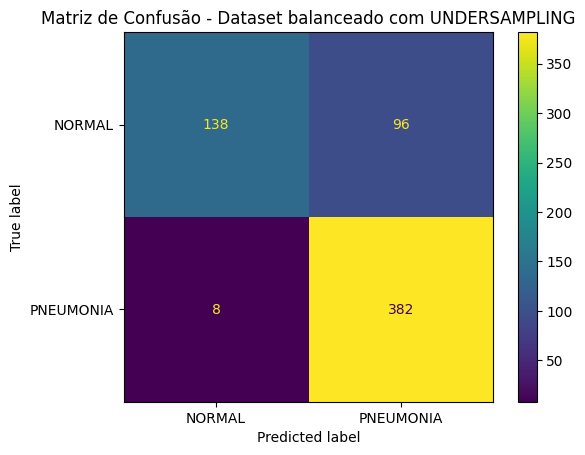

In [77]:
b_conf_matrix = confusion_matrix(b_all_labels, b_all_predictions)

disp = ConfusionMatrixDisplay(
    confusion_matrix=b_conf_matrix,
    display_labels=CLASS_NAMES
)

disp.plot(values_format="d")
plt.title("Matriz de Confusão - Dataset balanceado com UNDERSAMPLING")
plt.show()

### Experimento com o dataset balanceado por OVERSAMPLING

Neste terceiro experimento, o conjunto de **treinamento** foi balanceado por oversampling. Os conjuntos de **teste** e **validação** foram mantidos iguais ao dataset desbalanceado, sem oversampling, para que a avaliação final continue sendo feita sobre a mesma distribuição nos dois experimentos.

In [47]:
os_train_samples = read_samples_by_folder(OVERSAMPLED_DATA_ROOT, "train")
os_val_samples = read_samples_by_folder(OVERSAMPLED_DATA_ROOT, "val")
os_test_samples = read_samples_by_folder(OVERSAMPLED_DATA_ROOT, "test")

print_class_counts("Train", os_train_samples)
print_class_counts("Validation", os_val_samples)
print_class_counts("Test", os_test_samples)

total_os_images = len(os_train_samples) + len(os_val_samples) + len(os_test_samples)
print("Total images used:", total_os_images)

Train images: 6212
|--NORMAL: 3106
|--PNEUMONIA: 3106
Validation images: 1047
|--NORMAL: 270
|--PNEUMONIA: 777
Test images: 624
|--NORMAL: 234
|--PNEUMONIA: 390
Total images used: 7883


In [48]:

os_weights = EfficientNet_B0_Weights.DEFAULT
os_preprocess = os_weights.transforms()

os_train_dataset = ChestXRayDataset(os_train_samples, transform=os_preprocess)
os_val_dataset = ChestXRayDataset(os_val_samples, transform=os_preprocess)
os_test_dataset = ChestXRayDataset(os_test_samples, transform=os_preprocess)

In [49]:
os_train_loader = DataLoader(
    os_train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=pin_memory
)

os_val_loader = DataLoader(
    os_val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=pin_memory
)

os_test_loader = DataLoader(
    os_test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=pin_memory
)

In [50]:
os_model = models.efficientnet_b0(weights=os_weights)
for param in os_model.parameters():
    param.requires_grad = False
os_model.classifier[1] = nn.Linear(os_model.classifier[1].in_features, 1)

os_model = os_model.to(device)

In [51]:
# Inicia o treinamento

os_history, os_training_time_seconds, os_best_epoch, os_epochs_done = train_model(
    model=os_model,
    train_loader=os_train_loader,
    val_loader=os_val_loader,
    num_epochs=MAX_EPOCHS,
    learning_rate=LEARNING_RATE,
    patience=PATIENCE,
    best_model_path=OVERSAMPLED_BEST_MODEL_PATH
)

Epoch [1/20], Train Loss: 0.3402, Train Acc: 0.8896, Val Loss: 0.2300, Val Acc: 0.9274
Best model saved at epoch 1.
Epoch [2/20], Train Loss: 0.2119, Train Acc: 0.9269, Val Loss: 0.1820, Val Acc: 0.9370
Best model saved at epoch 2.
Epoch [3/20], Train Loss: 0.1841, Train Acc: 0.9316, Val Loss: 0.1818, Val Acc: 0.9351
Best model saved at epoch 3.
Epoch [4/20], Train Loss: 0.1723, Train Acc: 0.9354, Val Loss: 0.1651, Val Acc: 0.9398
Best model saved at epoch 4.
Epoch [5/20], Train Loss: 0.1622, Train Acc: 0.9396, Val Loss: 0.1622, Val Acc: 0.9379
Best model saved at epoch 5.
Epoch [6/20], Train Loss: 0.1556, Train Acc: 0.9427, Val Loss: 0.1398, Val Acc: 0.9522
Best model saved at epoch 6.
Epoch [7/20], Train Loss: 0.1418, Train Acc: 0.9486, Val Loss: 0.1699, Val Acc: 0.9351
No improvement for 1 epoch(s).
Epoch [8/20], Train Loss: 0.1502, Train Acc: 0.9435, Val Loss: 0.1469, Val Acc: 0.9484
No improvement for 2 epoch(s).
Epoch [9/20], Train Loss: 0.1373, Train Acc: 0.9482, Val Loss: 0.130

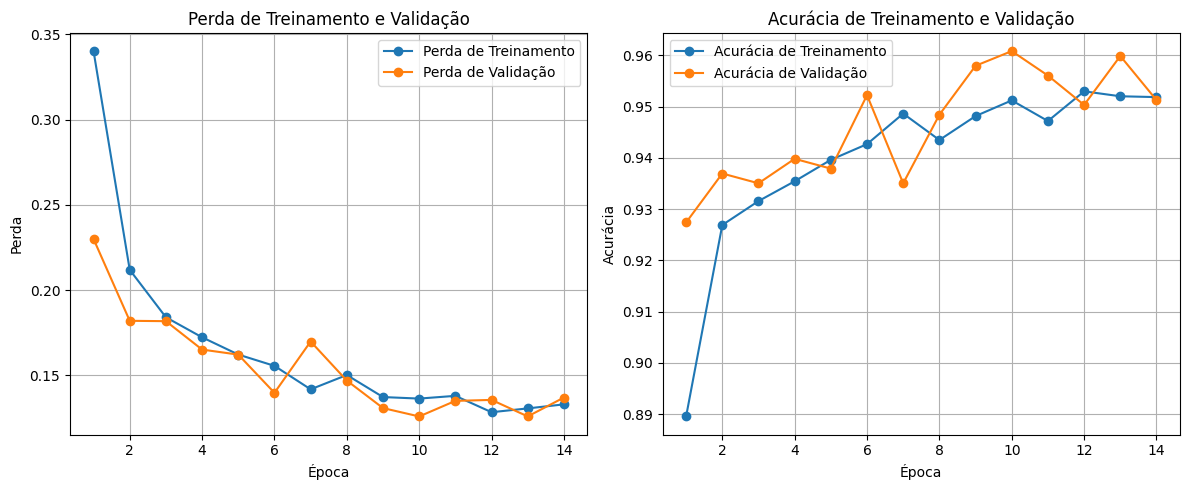

In [52]:
plot_training_curves(os_history)

In [65]:
os_model.load_state_dict(torch.load(OVERSAMPLED_BEST_MODEL_PATH, map_location=device, weights_only=True))
os_model = os_model.to(device)

print("Loaded best model:", OVERSAMPLED_BEST_MODEL_PATH)

os_all_labels, os_all_predictions, os_all_probabilities = evaluate_model(
    os_model,
    os_test_loader,
    threshold=FINAL_THRESHOLD
)

Loaded best model: trained-models/best_mobilenetv2_oversampled.pth
Threshold: 0.5
Test Accuracy: 0.8285
Test Precision: 0.7954
Test Recall: 0.9769
Test F1 Score: 0.8769

Classification Report:
              precision    recall  f1-score   support

      NORMAL       0.94      0.58      0.72       234
   PNEUMONIA       0.80      0.98      0.88       390

    accuracy                           0.83       624
   macro avg       0.87      0.78      0.80       624
weighted avg       0.85      0.83      0.82       624



In [54]:
threshold_rows = []

for th in [0.50, 0.55, 0.60, 0.65, 0.70]:
    preds = [1 if p >= th else 0 for p in os_all_probabilities]

    row = {
        "threshold": th,
        "accuracy": accuracy_score(os_all_labels, preds),
        "precision": precision_score(os_all_labels, preds, zero_division=0),
        "recall": recall_score(os_all_labels, preds, zero_division=0),
        "f1_score": f1_score(os_all_labels, preds, zero_division=0),
    }

    threshold_rows.append(row)

threshold_df = pd.DataFrame(threshold_rows)
display(threshold_df)

,threshold,accuracy,precision,recall,f1_score
0,0.50,0.828526,0.795407,0.976923,0.876870
1,0.55,0.836538,0.803797,0.976923,0.881944
2,0.60,0.844551,0.813704,0.974359,0.886814
3,0.65,0.852564,0.825328,0.969231,0.891509
4,0.70,0.863782,0.841163,0.964103,0.898447


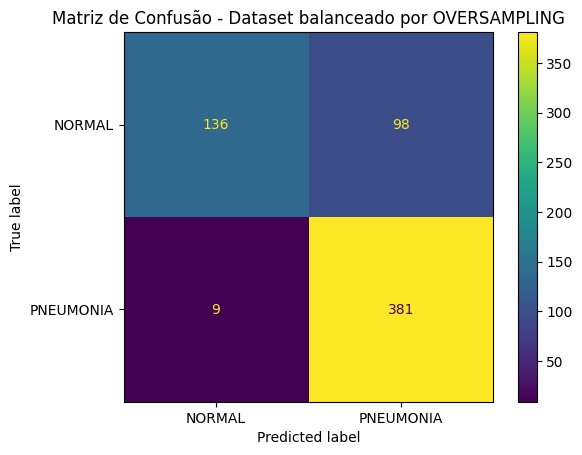

In [66]:
os_conf_matrix = confusion_matrix(os_all_labels, os_all_predictions)

disp = ConfusionMatrixDisplay(
    confusion_matrix=os_conf_matrix,
    display_labels=CLASS_NAMES
)

disp.plot(values_format="d")
plt.title("Matriz de Confusão - Dataset balanceado por OVERSAMPLING")
plt.show()

### Conclusão

Este experimento teve como objetivo avaliar o desempenho de uma rede neural convolucional aplicada à classificação de radiografias de tórax em duas classes: **NORMAL** e **PNEUMONIA**. Para isso, foi utilizada uma abordagem de **aprendizado por transferência**, na qual um modelo pré-treinado foi adaptado para a tarefa de classificação binária. O conjunto de teste foi mantido fixo em todos os experimentos, contendo **234 imagens da classe NORMAL** e **390 imagens da classe PNEUMONIA**, o que permitiu uma comparação mais justa entre as estratégias avaliadas.

Foram analisados três cenários principais: treinamento com o conjunto **desbalanceado**, treinamento com balanceamento por **undersampling** e treinamento com balanceamento por **oversampling**. De forma geral, todos os modelos apresentaram bom desempenho na identificação da classe **PNEUMONIA**, com valores elevados de *recall*. Esse resultado é importante no contexto de apoio ao diagnóstico médico, pois indica que o modelo foi capaz de identificar a maioria dos casos positivos de pneumonia, reduzindo a quantidade de falsos negativos.

No primeiro experimento, utilizando o dataset desbalanceado, o modelo apresentou, com *threshold* igual a 0,5, acurácia de **0,8141**, precisão de **0,7740**, *recall* de **0,9923** e F1-score de **0,8697**. O alto *recall* para a classe **PNEUMONIA** indica que o modelo praticamente não deixou de identificar casos positivos. Entretanto, esse comportamento veio acompanhado de uma menor capacidade de reconhecer corretamente imagens da classe **NORMAL**, cujo *recall* foi de apenas **0,52**. Isso sugere que o modelo treinado em dados desbalanceados tende a favorecer a classe majoritária, classificando muitas imagens normais como pneumonia.

No segundo experimento, com balanceamento por **undersampling**, houve uma melhora em relação ao modelo desbalanceado. Com *threshold* igual a 0,5, a acurácia subiu para **0,8333**, a precisão para **0,7992** e o F1-score para **0,8802**, mantendo ainda um *recall* elevado de **0,9795** para pneumonia. Esse resultado mostra que o balanceamento do conjunto de treinamento contribuiu para reduzir parcialmente o viés em direção à classe majoritária, melhorando a precisão geral do modelo sem comprometer significativamente a sensibilidade para a detecção de pneumonia.

Além disso, no experimento com undersampling foram realizados testes adicionais variando o valor do *threshold* entre **0,5** e **0,7**. Os resultados mostraram que o aumento do *threshold* produziu uma melhora gradual na acurácia, na precisão e no F1-score, enquanto o *recall* apresentou uma pequena redução. O melhor resultado global entre os valores testados ocorreu com *threshold* igual a **0,7**, atingindo acurácia de **0,8670**, precisão de **0,8449**, *recall* de **0,9641** e F1-score de **0,9006**.

| Threshold | Acurácia | Precisão | Recall | F1-score |
| --------: | -------: | -------: | -----: | -------: |
|      0,50 |   0,8333 |   0,7992 | 0,9795 |   0,8802 |
|      0,55 |   0,8397 |   0,8098 | 0,9718 |   0,8834 |
|      0,60 |   0,8478 |   0,8186 | 0,9718 |   0,8886 |
|      0,65 |   0,8558 |   0,8289 | 0,9692 |   0,8936 |
|      0,70 |   0,8670 |   0,8449 | 0,9641 |   0,9006 |

A análise desses valores indica que o ajuste do *threshold* teve papel importante na melhoria do desempenho do classificador. Ao elevar o limiar de decisão, o modelo passou a exigir maior confiança para classificar uma imagem como **PNEUMONIA**, o que reduziu a quantidade de falsos positivos e aumentou a precisão. Por outro lado, essa mudança também reduziu levemente o *recall*, indicando um pequeno aumento no risco de falsos negativos. Mesmo assim, com *threshold* de **0,7**, o *recall* permaneceu alto, em **0,9641**, mantendo boa capacidade de detecção da doença.

No terceiro experimento, com **oversampling**, o modelo também apresentou desempenho superior ao cenário desbalanceado. Com *threshold* igual a 0,5, foram obtidos acurácia de **0,8285**, precisão de **0,7954**, *recall* de **0,9769** e F1-score de **0,8769**. Ao variar o *threshold*, o desempenho também melhorou, alcançando F1-score de **0,8984** com *threshold* igual a **0,7**. No entanto, esse resultado ficou ligeiramente abaixo do obtido pelo modelo com undersampling no mesmo *threshold*, cujo F1-score foi de **0,9006**.

Comparando os três cenários, observa-se que as estratégias de balanceamento contribuíram para melhorar o desempenho do modelo em relação ao treinamento com dados desbalanceados. O **undersampling**, especialmente combinado ao ajuste do *threshold*, apresentou o melhor resultado geral entre os experimentos analisados. Esse resultado sugere que, para este conjunto de dados e para a configuração adotada, reduzir o desbalanceamento no treinamento ajudou o modelo a aprender uma fronteira de decisão mais equilibrada entre as classes.

Apesar dos bons resultados, é importante destacar que o problema envolve imagens médicas, portanto a avaliação do modelo não deve se limitar apenas à acurácia. Métricas como *recall*, precisão, F1-score e matriz de confusão são fundamentais para interpretar o comportamento do classificador. Em aplicações clínicas, falsos negativos podem ser mais críticos, pois indicam casos de pneumonia não detectados. Por isso, a escolha do *threshold* deve considerar o objetivo da aplicação: valores menores favorecem maior sensibilidade, enquanto valores maiores tendem a melhorar a precisão e reduzir falsos alarmes.

Conclui-se que o uso de redes neurais convolucionais com aprendizado por transferência se mostrou adequado para a tarefa de classificação de radiografias de tórax. O experimento demonstrou que o tratamento do desbalanceamento das classes e o ajuste do *threshold* de decisão são etapas importantes para melhorar o desempenho do modelo. Entre as configurações avaliadas, o modelo treinado com **undersampling** e avaliado com *threshold* igual a **0,7** apresentou o melhor equilíbrio entre acurácia, precisão, *recall* e F1-score, sendo a configuração mais promissora entre as analisadas neste trabalho.